## Hartman-Grobman Theorem
$\newcommand{\xstar}{x^{\star}}$
$\newcommand{\R}{{\Bbb R}}$
https://en.wikipedia.org/wiki/Hartman–Grobman_theorem

### Hypotheses
1. Let $U$ be an **open neighborhood** of $x^{\star}$ in ${\Bbb R}^n$.  That is $U$ is open (all points of $U$ are interior points) and contains $x^{\star}$.

2. Let $f:U\to{\Bbb R}^n$ be $C^{1}$ on $U$ (continuous partial derivatives of the components w.r.t. the usual coordinates).

3. Let $J$ be the Jacobian matrix
$$
    J = [J_{ij}] = [\partial f_i/\partial x_j].
$$

4. Let $\phi(t,y_0)=\phi^t(y_0)=\phi_{y_0}(t)$ be the **flow** for 
\begin{equation}
    \dot y = f(y),\qquad y(0)=y_0. \tag{IVP}
\end{equation}
That is, for each initial condition $y_0\in U$, $\phi_{y_0}(t)$ satisfies (IVP) on some open interval about $t=0$. 

5. Suppose $x^{\star}$ is an **equilibrium point** (or **fixed point**) for $f$.  That is, $f(x^{\star})=0$ hence
$$
    \phi(t,x^{\star}) \equiv x^{\star}.
$$

6. Suppose $A=J(x^{\star})$ is **hyperbolic**.  That is, all eigenvalues of $A$ have nonzero real part.

### Conclusion
#### Then
1. there is a **neighborhood** $N$ of $x^{\star}$ (a set with $x^{\star}$ in its interior), 

2. a neighborhood $V$ of $0$ in ${\Bbb R}^n$, and

3. a **homeomorphism** $h:N\to V$, that is $h$ is continuous, invertible, and its inverse is continuous

#### such that
* under the change of coordinates $x=h(y)$ the flow $\phi$ is topologically conjugate to the flow for the linear system
$$
    \dot x = Ax\qquad x(t_0) = x_0
$$
which as we now know is $e^{At}x_0$.  That is, $h(\phi(t,y_0))=e^{At}x_0$ with $x_0=h(y_0)$.

## Linear Systems in ${\Bbb R}^2$.

Two distinct real eigenvalues (or one of geometric multiplicity two).
$$
    J_1 = \begin{bmatrix} \lambda_1 & 0 \cr 0 & \lambda_2 \end{bmatrix}
$$

A complex congjugate pair of eigenvalues
$$
    J_2 = \begin{bmatrix} \alpha & \beta \cr -\beta & \alpha \end{bmatrix}
$$

Exactly one eigenvalue of geometric multiplicity one
$$
    J_3 = \begin{bmatrix} \lambda_1 & 1 \cr 0 & \lambda_1 \end{bmatrix}
$$

## Pendulum problem, ignoring friction
Total energy
$$
    E = -mg\ell\cos\theta + {1\over 2} m \ell^2(\dot\theta)^2.
$$

Conservation of energy implies
$$
        0 = mg\ell \sin\theta \dot\theta + m\ell^2\dot\theta\ddot\theta
$$
or
$$
    \ddot\theta =-{g\over\ell}\sin\theta
$$

## Friction included
$$
    \ddot\theta =-{g\over\ell}\sin\theta - 2\alpha \dot\theta
$$
or as a first order system with
$x_1=\theta$, $x_2=\dot\theta$

\begin{align}
    \dot x_1 &= x_2\cr
    \dot x_2 &= -\frac{g}{\ell}\sin(x_1) - 2\alpha x_2\cr
\end{align}

## Imports

In [7]:
import numpy as np, numpy.linalg as LA, math
from math import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

## Functions and parameters

In [4]:
g,ℓ = 9.81,1.0
α = 0.1
a,b = -π-1,π+1 # x limits
c,d = -6,6     # y limits

# Energy divided by m\ell
f = lambda x1, x2: -2*g*np.cos(x1) + ℓ*x2**2

def pend(t,xx):
    x1, x2 = xx
    return [x2,-g*math.sin(x1)/ℓ-2*α*x2]

J = lambda x1, x2: np.array([[0,1],[-(g/ℓ)*np.cos(x1),-2*α]])

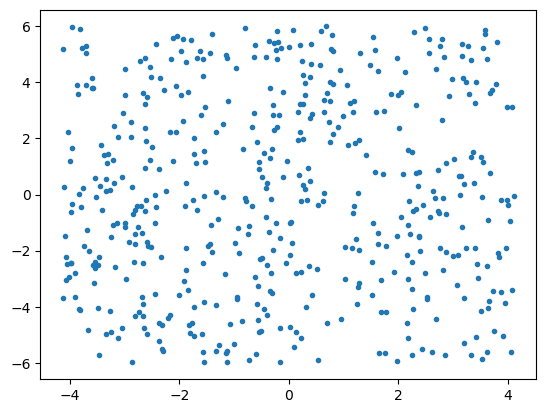

In [5]:
t0,t1 = 0.,20.
Nsols = 500
x10s = (b-a)*np.random.rand(Nsols)+a
x20s = (c-d)*np.random.rand(Nsols)+d
x1x20s = np.vstack((x10s,x20s)).T
t_span = [t0,t1]
plt.plot(x10s,x20s,'.')

<IPython.core.display.Javascript object>


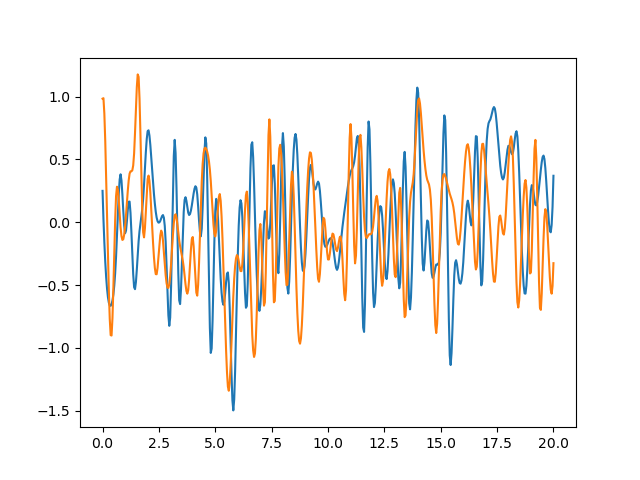

In [18]:
#ε = 1e-3
#ε = 1e-2
#ε = 1e-1
ε = 5e-1

noise_steps = 100
tsteps = 500

t_noise = np.linspace(t0,t1,noise_steps+1)
t_eval = np.linspace(t0,t1,tsteps+1)

noise = CubicSpline(t_noise,ε*np.random.randn(2,noise_steps+1),axis=1)
plt.plot(t_eval,noise(t_eval).T)

In [11]:
def noisy_pend(t,xx):
    x1, x2 = xx
    return noise(t)+[x2,-g*math.sin(x1)/ℓ-2*α*x2]

In [12]:
%matplotlib notebook

<IPython.core.display.Javascript object>


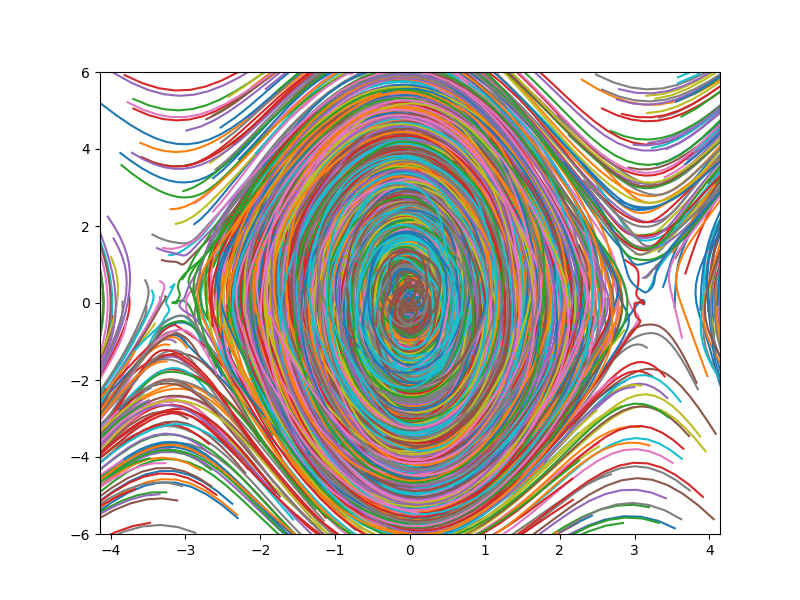

In [19]:
sols = []
for x10x20 in x1x20s:
    sol = solve_ivp(noisy_pend,t_span,x10x20,t_eval=t_eval)
    sols.append(sol)

fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

### Van der Pol Oscillator
$$
    {d^2x\over dt^2}-\mu(1-x^2){dx\over dt}+x = 0
$$
or as a system
\begin{align}
\dot x_1 & = x_2 \cr
\dot x_2 &= \mu(1-x_1^2)x_2-x_1\cr
\end{align}
https://en.wikipedia.org/wiki/Van_der_Pol_oscillator

Notice that $(0,0)$ is the only fixed point and the Jacobian of the vector field is
$$
    J = \begin{bmatrix} 0 & 1\cr -1 - 2\mu x_1 x_2 & \mu(1-x_1^2)\cr\end{bmatrix}.
$$

If $(x_1,x_2)$ is a equilibrium point then $x_2=0$ from the first component.  Then $x_1=0$ as well.  That is $(0,0)$ is the only equilibrium point for this system.

In particular, at $(0,0)$ the Jacobian is
$$
    J(0,0) = \begin{bmatrix} 0 & 1\cr -1  & \mu\cr\end{bmatrix}.
$$

In [20]:
from sympy import symbols, Matrix, diff
x1,x2,μ = symbols('x_1 x_2 μ')
J = Matrix([
    [0,1],[-1-2*μ*x1*x2,μ*(1-x1**2)]
])
J

Matrix([
[               0,              1],
[-2*x_1*x_2*μ - 1, μ*(1 - x_1**2)]])

In [22]:
J.subs(x1,0).subs(x2,0).charpoly()

PurePoly(lambda**2 - μ*lambda + 1, lambda, domain='ZZ[μ]')

In [26]:
Matrix(list(J.subs(x1,0).subs(x2,0).eigenvals().keys()))

Matrix([
[μ/2 - sqrt((μ - 2)*(μ + 2))/2],
[μ/2 + sqrt((μ - 2)*(μ + 2))/2]])

## Functions and parameters

In [27]:
μ = 1.
def J(x1,x2):
    return np.array([[0,1],[-1-2*μ*x1*x2,μ*(1-x1**2)]])
def vanderpol(t,xx):
    x1,x2 = xx
    return [x2,μ*(1-x1**2)*x2 - x1]

### Region of study
The restrictions
$$
    a\le x_1 \le b \quad c\le x_2 \le c
$$
define a rectangular region $R$.

<IPython.core.display.Javascript object>


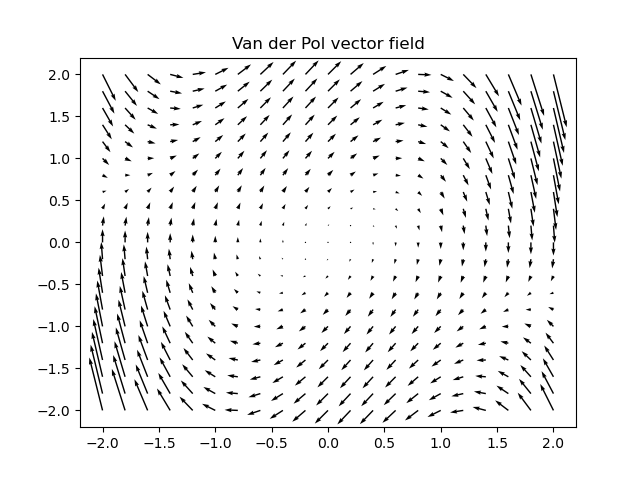

Text(0.5, 1.0, 'Van der Pol vector field')

In [32]:
a,b = -2,2 # x1 limits
c,d = -2,2 # x2 limits
npts  = 21
x1 = np.linspace(a,b,npts)
x2 = np.linspace(c,d,npts)
X1,X2 = np.meshgrid(x1,x2)
Z1,Z2 = vanderpol(_,(X1,X2))
plt.quiver(X1,X2,Z1,Z2)
plt.title('Van der Pol vector field')

In [33]:
a,b = -5,5 # x1 limits
c,d = -6,6 # x2 limits

## Time interval and Initial Conditions
$$
    (x_{10},x_{20})\in R,\qquad t_0\le t\le t_1
$$

In [34]:
t0,t1 = 0.,40.
Nsols = 1200
x10s = (b-a)*np.random.rand(Nsols)+a
x20s = (c-d)*np.random.rand(Nsols)+d
y0s = np.vstack((x10s,x20s)).T
t_span = [t0,t1]

tsteps = 800
t_eval = np.linspace(t0,t1,tsteps+1)

In [36]:
LA.eig(J(0,0))[0]

array([0.5+0.8660254j, 0.5-0.8660254j])

In [37]:
%%time
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))

CPU times: user 19.7 s, sys: 34.2 ms, total: 19.7 s
Wall time: 19.7 s


<IPython.core.display.Javascript object>


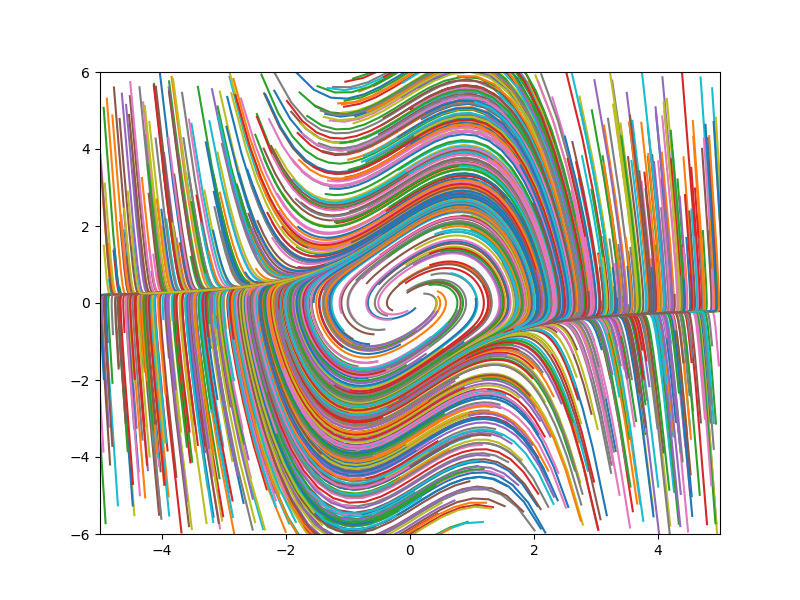

In [39]:
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

<IPython.core.display.Javascript object>


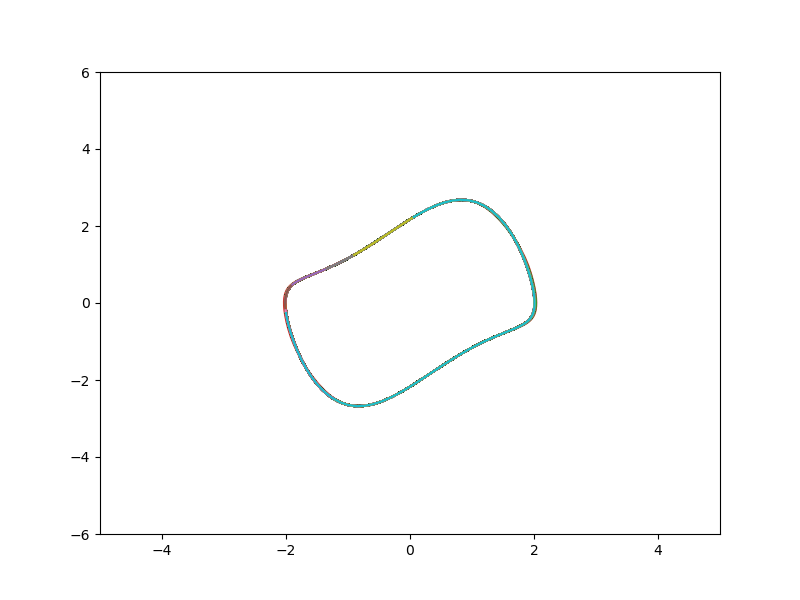

In [40]:
start = 400
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,start:frame], sol.y[1,start:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(start+1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

<IPython.core.display.Javascript object>


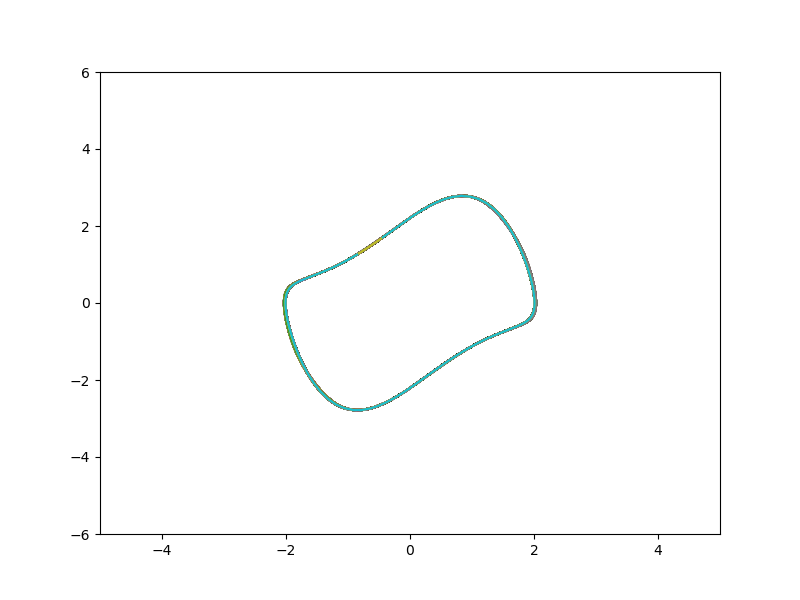

In [41]:
μ = 1.1
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))

start = 400
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,start:frame], sol.y[1,start:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(start+1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

<IPython.core.display.Javascript object>


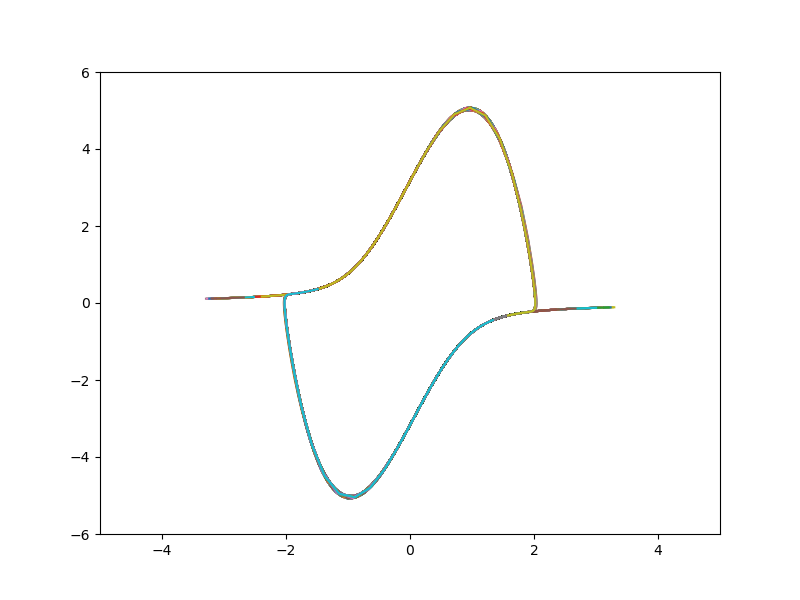

In [42]:
μ = 3.
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))

start = 400
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,start:frame], sol.y[1,start:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(start+1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

<IPython.core.display.Javascript object>


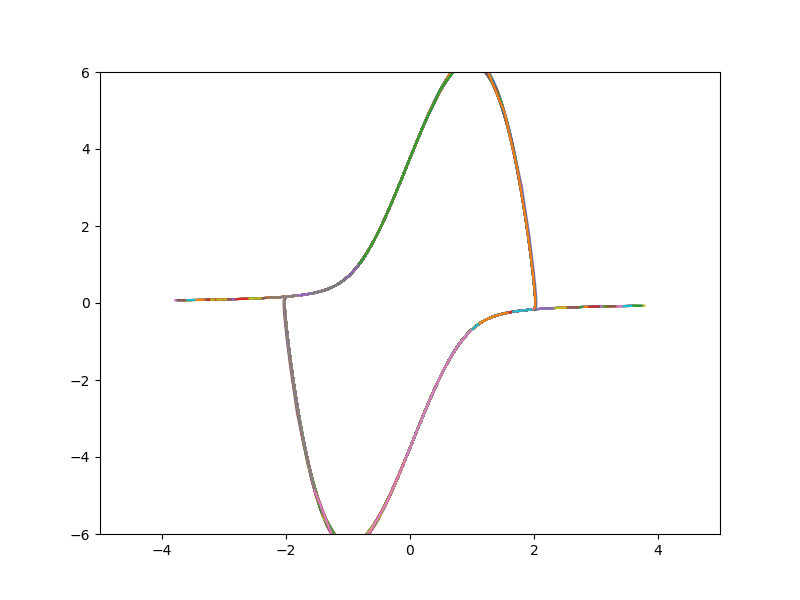

In [43]:
μ = 4.
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))

start = 400
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,start:frame], sol.y[1,start:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(start+1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

<IPython.core.display.Javascript object>


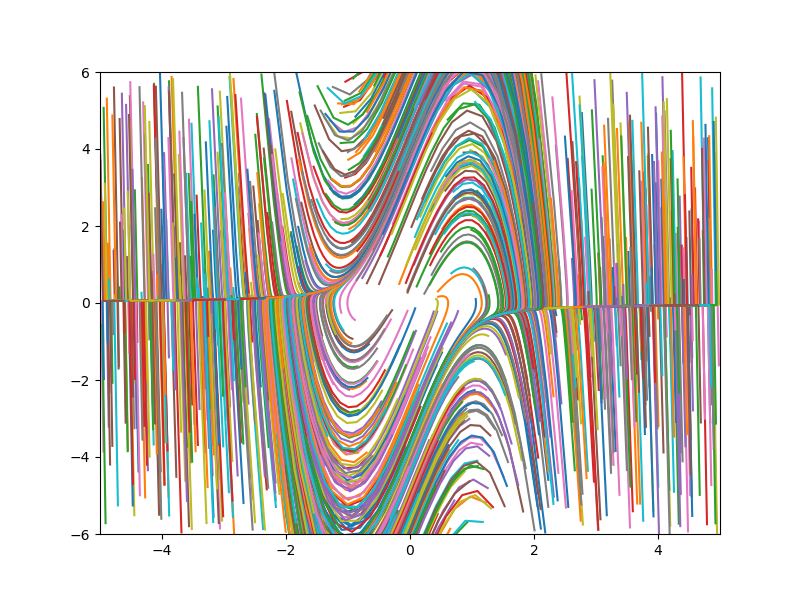

In [44]:
start = 0
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,start:frame], sol.y[1,start:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(start+1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

<IPython.core.display.Javascript object>


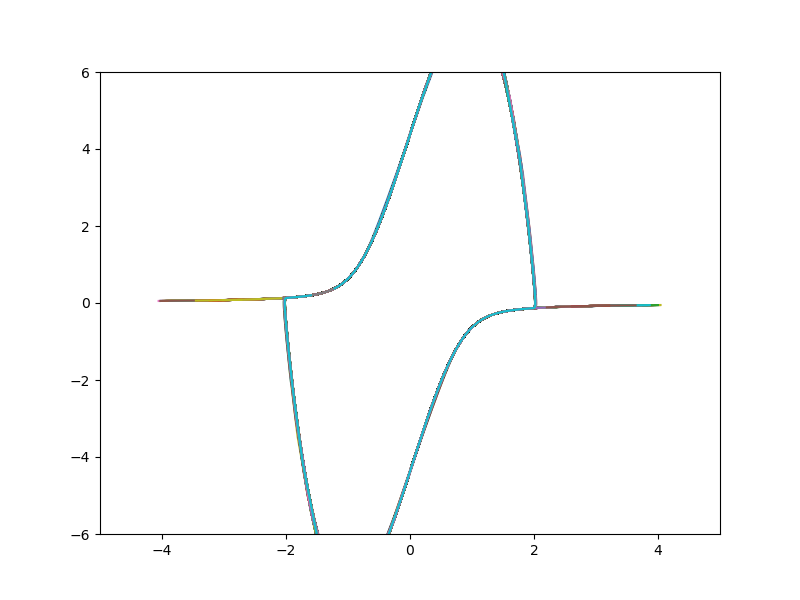

In [45]:
μ = 5.
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,t_eval=t_eval))

start = 400
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,start:frame], sol.y[1,start:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(start+1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

## Poincare-Bendixson Theorem
https://en.wikipedia.org/wiki/Poincar%C3%A9%E2%80%93Bendixson_theorem

Suppose $R$ is a closed annular region of the plane which is forward invariant under the flow for
$$
    \dot x = f(x)
$$
where $f$ is $C^1$ on some open set containing $R$.  Suppose further that $R$ contains no fixed points for $f$.  Then any orbit starting in $R$ either
1. is a closed periodic orbit, or
2. spirals towards a periodic orbit as $t\to\infty$.